## TRN Map

In [1]:
from pymodulon.core import IcaData
from pymodulon.plotting import *
from os import path
import pandas as pd
import re
from Bio.KEGG import REST
from tqdm.notebook import tqdm
from pymodulon.io import *
from pymodulon.compare import *
from datetime import datetime, timedelta
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu, median_abs_deviation, pearsonr, skew
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import StandardScaler
import pylab

pd.set_option('display.max_columns', 100, 'display.max_rows', 100)

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [3]:
ica_data = load_json_model('C:\\Users\\99hee\\precise_mg1655\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')

## Fig. 6A

In [4]:
gene_im_df = pd.DataFrame(ica_data.M_binarized.sum(axis=1).sort_values(ascending=False), columns=['n_ims']).merge(
    ica_data.gene_table, how='left', left_index=True, right_index=True)

In [5]:
gene_im_df.head()

,n_ims,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,regulator,in_iM
b2207,4.0,napD,U00096.3,NaN,2302750,2303013,-,NapA signal peptide-binding chaperone NapD,Inorganic ion transport and metabolism,P0A9I5,Op2181,"Fnr,ModE,NarP,NarL,IscR,RpoD,FlhDC",True
b4072,4.0,nrfC,U00096.3,NaN,4289808,4290479,+,putative menaquinol-cytochrome c reductase 4Fe...,Energy production and conversion,P0AAK7,Op3980,"NarP,Fnr,IHF,NarL,NsrR,Fis,RpoD,FlhDC",True
b4662,4.0,sgrT,U00096.3,NaN,77388,77519,+,PtsG glucose transporter inhibitor,Energy production and conversion,C1P5Z7,Op69,"SgrR,Cra,RpoS,RpoD,ppGpp,DksA",True
b4601,4.0,ydgU,U00096.3,NaN,1671777,1671860,+,uncharacterized protein YdgU,No COG annotation,A5A617,Op1583,NaN,True
b2018,4.0,hisL,U00096.3,NaN,2089996,2090046,+,his operon leader peptide,No COG annotation,P60995,Op1996,"ArgR,DksA",True


In [6]:
# gene_im_df.loc[(gene_im_df.n_ims == 4) | (gene_im_df.n_ims == 3)].to_csv('TRN_map_genes.csv')

In [6]:
##### iM composition based on n_iMs col

multi_iM_dict = {}

for iM in ica_data.imodulon_table.index.values:
    multi_iM_dict[iM] = dict(gene_im_df.loc[ica_data.view_imodulon(iM).index.values].value_counts('n_ims'))
    
multi_iM_dict

{'Maltose': {1.0: 10},
 'Crp': {1.0: 15, 2.0: 13, 3.0: 4},
 'UC-3': {1.0: 6, 2.0: 1},
 'Glycolate': {1.0: 6},
 'RpoS': {1.0: 87, 2.0: 30, 3.0: 1},
 'SG_1': {1.0: 1, 2.0: 1},
 'SG_2': {4.0: 2, 1.0: 1, 2.0: 1},
 'Translation': {1.0: 31},
 'Fnr-2': {1.0: 21, 2.0: 10, 3.0: 4, 4.0: 2},
 'DNA Damage': {1.0: 19, 2.0: 2, 4.0: 1},
 'ArcA-2': {1.0: 19, 2.0: 11, 3.0: 6, 4.0: 1},
 'SG_3': {2.0: 2},
 'RcsAB': {1.0: 24, 2.0: 4, 3.0: 1},
 'SG_4': {1.0: 1},
 'ArcA-1': {1.0: 16, 3.0: 4, 2.0: 3},
 'Histidine': {1.0: 7},
 'FliA': {1.0: 23, 2.0: 7, 3.0: 1},
 'Tryptophan': {1.0: 5, 2.0: 2, 3.0: 1},
 'Membrane': {1.0: 4, 2.0: 2, 3.0: 1},
 'SG_5': {1.0: 1},
 'UC-4': {2.0: 6, 1.0: 5, 4.0: 1},
 'N Reduction': {1.0: 14, 2.0: 5, 3.0: 5, 4.0: 2},
 'Fur-1': {1.0: 25, 2.0: 18},
 'SG_6': {2.0: 2, 3.0: 2},
 'SG_7': {2.0: 1, 4.0: 1},
 'Gluconate': {1.0: 9},
 'SoxS': {1.0: 11, 2.0: 3, 3.0: 3},
 'Zinc': {1.0: 6, 2.0: 2, 3.0: 1},
 'Sorbitol': {1.0: 7},
 'GlcNAc': {1.0: 8, 2.0: 3},
 'YmfT': {1.0: 9, 2.0: 2, 3.0: 1},
 'UC-

In [7]:
#### dictionary of iModulons that contains genes that are not present within any other iModulon
#### these iModulons are the least complex/connected in the TRN

no_shared_iMs = {}

for iM in multi_iM_dict.keys():
    # ignoring SG iMs
    if iM.__contains__('SG_') == False:
        # setting highest key value as 1
        if max(multi_iM_dict[iM].keys()) == 1:
            no_shared_iMs[iM] = dict(gene_im_df.loc[ica_data.view_imodulon(iM).index.values].value_counts('n_ims'))
                
no_shared_iMs

{'Maltose': {1.0: 10},
 'Glycolate': {1.0: 6},
 'Translation': {1.0: 31},
 'Histidine': {1.0: 7},
 'Gluconate': {1.0: 9},
 'Sorbitol': {1.0: 7},
 'Fimbriae': {1.0: 7},
 'RpoH': {1.0: 18},
 'Sugar Diacid': {1.0: 9},
 'FHL': {1.0: 8},
 'YhaJ': {1.0: 8},
 'Thre/Ser': {1.0: 9},
 'Propionate': {1.0: 4},
 'Glycerol': {1.0: 8},
 'Methionine': {1.0: 16},
 'SlyA': {1.0: 5},
 'Glycine': {1.0: 4},
 'Potassium': {1.0: 6},
 'Arabinose': {1.0: 9},
 'Curli': {1.0: 7},
 'Osmoprotectant': {1.0: 3},
 'Cra': {1.0: 6},
 'Thiamine': {1.0: 9},
 'Rhamnose': {1.0: 6},
 'Biotin': {1.0: 5},
 'Biofilm': {1.0: 4}}

In [18]:
ica_data.imodulon_table.loc[no_shared_iMs.keys()].value_counts('functional_category')

functional_category
carbon metabolism           11
amino acid metabolism        4
extracellular structures     3
cofactor metabolism          2
energy metabolism            1
envelope stress              1
metal homeostasis            1
temperature shock            1
translation                  1
unknown                      1
dtype: int64

In [19]:
#### dictionary of iModulons that contains genes that are at most present within ONE other iModulon
#### these iModulons are the 2nd least complex/connected in the TRN

two_shared_iMs = {}

for iM in multi_iM_dict.keys():
    # ignoring SG iMs
    if iM.__contains__('SG_') == False:
        # setting highest key value as 2
        if max(multi_iM_dict[iM].keys()) == 2:
            two_shared_iMs[iM] = dict(gene_im_df.loc[ica_data.view_imodulon(iM).index.values].value_counts('n_ims'))
                
two_shared_iMs

{'UC-3': {1.0: 6, 2.0: 1},
 'Fur-1': {1.0: 25, 2.0: 18},
 'GlcNAc': {1.0: 8, 2.0: 3},
 'Nucleoside': {1.0: 6, 2.0: 3},
 'Sialic Acid': {1.0: 10, 2.0: 3},
 'Lrp-1': {1.0: 8, 2.0: 1},
 'FrmR': {1.0: 3, 2.0: 2},
 'Isc System': {1.0: 4, 2.0: 2},
 'Galactose': {1.0: 11, 2.0: 3},
 'Nickel': {1.0: 4, 2.0: 1},
 'Putrescine': {1.0: 7, 2.0: 1},
 'Microaerobic': {1.0: 9, 2.0: 2},
 'Salicylic Acid': {1.0: 4, 2.0: 2},
 'UC-10': {1.0: 8, 2.0: 2},
 'Arginine': {1.0: 16, 2.0: 2},
 'Sulfate': {1.0: 7, 2.0: 3},
 'FlhDC-2': {1.0: 22, 2.0: 14},
 'Lysine/T2SS': {1.0: 3, 2.0: 2},
 'Leucine/Dipeptide': {2.0: 8},
 'Glutarate': {2.0: 9, 1.0: 1},
 'NtrC-2': {1.0: 4, 2.0: 4}}

In [20]:
ica_data.imodulon_table.loc[two_shared_iMs.keys()].value_counts('functional_category')

functional_category
amino acid metabolism       6
carbon metabolism           3
metal homeostasis           2
nitrogen metabolism         2
unknown                     2
cofactor metabolism         1
energy metabolism           1
extracellular structures    1
formaldehyde metabolism     1
nucleotide metabolism       1
redox stress                1
dtype: int64

In [21]:
#### dictionary of iModulons that contains genes that are at most present within TWO other iModulons
#### these iModulons are moderately complex/connected in the TRN

three_shared_iMs = {}

for iM in multi_iM_dict.keys():
    # ignoring SG iMs
    if iM.__contains__('SG_') == False:
        # setting highest key value as 3
        if max(multi_iM_dict[iM].keys()) == 3:
            three_shared_iMs[iM] = dict(gene_im_df.loc[ica_data.view_imodulon(iM).index.values].value_counts('n_ims'))
                
three_shared_iMs

{'Crp': {1.0: 15, 2.0: 13, 3.0: 4},
 'RpoS': {1.0: 87, 2.0: 30, 3.0: 1},
 'RcsAB': {1.0: 24, 2.0: 4, 3.0: 1},
 'ArcA-1': {1.0: 16, 3.0: 4, 2.0: 3},
 'FliA': {1.0: 23, 2.0: 7, 3.0: 1},
 'Tryptophan': {1.0: 5, 2.0: 2, 3.0: 1},
 'Membrane': {1.0: 4, 2.0: 2, 3.0: 1},
 'SoxS': {1.0: 11, 2.0: 3, 3.0: 3},
 'Zinc': {1.0: 6, 2.0: 2, 3.0: 1},
 'YmfT': {1.0: 9, 2.0: 2, 3.0: 1},
 'UC-5': {1.0: 17, 2.0: 7, 3.0: 1},
 'Pyrimidine': {1.0: 7, 2.0: 3, 3.0: 1},
 'Purine': {1.0: 22, 3.0: 1},
 'Fur-2': {1.0: 14, 2.0: 14, 3.0: 1},
 'UC-6': {1.0: 11, 2.0: 6, 3.0: 3},
 'UxuR': {1.0: 12, 2.0: 1, 3.0: 1},
 'Leu/Val/Ile': {1.0: 7, 3.0: 1},
 'UC-8': {2.0: 7, 1.0: 5, 3.0: 1},
 'LPS': {1.0: 44, 2.0: 14, 3.0: 4},
 'Copper': {1.0: 9, 3.0: 1},
 'FDH-N/NRA': {2.0: 6, 3.0: 3, 1.0: 2},
 'GadX': {1.0: 16, 2.0: 2, 3.0: 1},
 'UC-9': {1.0: 30, 2.0: 24, 3.0: 6},
 'Cold Shock': {2.0: 7, 1.0: 5, 3.0: 1},
 'TyrR': {1.0: 4, 2.0: 3, 3.0: 1},
 'CpxR': {1.0: 26, 2.0: 8, 3.0: 1},
 'NtrC-1': {1.0: 27, 2.0: 15, 3.0: 1},
 'UC-1': {1.0: 

In [22]:
ica_data.imodulon_table.loc[three_shared_iMs.keys()].value_counts('functional_category')

functional_category
unknown                     5
envelope stress             4
amino acid metabolism       3
extracellular structures    3
metal homeostasis           3
carbon metabolism           2
energy metabolism           2
nucleotide metabolism       2
DNA damage                  1
global stress               1
nitrogen metabolism         1
redox stress                1
temperature shock           1
dtype: int64

In [23]:
#### dictionary of iModulons that contains genes that are at most present within THREE other iModulons
#### these iModulons are the most complex/connected in the TRN

four_shared_iMs = {}

for iM in multi_iM_dict.keys():
    # ignoring SG iMs
    if iM.__contains__('SG_') == False:
        # setting highest key value as 4
        if max(multi_iM_dict[iM].keys()) == 4:
            four_shared_iMs[iM] = dict(gene_im_df.loc[ica_data.view_imodulon(iM).index.values].value_counts('n_ims'))
                
four_shared_iMs

{'Fnr-2': {1.0: 21, 2.0: 10, 3.0: 4, 4.0: 2},
 'DNA Damage': {1.0: 19, 2.0: 2, 4.0: 1},
 'ArcA-2': {1.0: 19, 2.0: 11, 3.0: 6, 4.0: 1},
 'UC-4': {2.0: 6, 1.0: 5, 4.0: 1},
 'N Reduction': {1.0: 14, 2.0: 5, 3.0: 5, 4.0: 2},
 'Phosphate': {1.0: 56, 2.0: 8, 3.0: 5, 4.0: 5},
 'UC-2': {1.0: 8, 2.0: 3, 4.0: 1},
 'UC-7': {1.0: 6, 2.0: 5, 3.0: 5, 4.0: 1},
 'EvgA': {1.0: 12, 2.0: 2, 4.0: 1},
 'BasR': {1.0: 5, 2.0: 1, 4.0: 1},
 'Fnr-1': {2.0: 16, 3.0: 8, 1.0: 7, 4.0: 2},
 'Fucose': {1.0: 7, 2.0: 2, 4.0: 1},
 'Lrp-2': {2.0: 19, 1.0: 17, 4.0: 2},
 'Cysteine': {1.0: 24, 2.0: 6, 3.0: 1, 4.0: 1},
 'Resistance': {2.0: 13, 1.0: 11, 3.0: 4, 4.0: 3},
 'ldrD': {1.0: 4, 2.0: 2, 4.0: 2}}

In [24]:
ica_data.imodulon_table.loc[four_shared_iMs.keys()].value_counts('functional_category')

functional_category
energy metabolism           4
unknown                     4
amino acid metabolism       2
envelope stress             2
DNA damage                  1
carbon metabolism           1
extracellular structures    1
phosphate metabolism        1
dtype: int64

In [25]:
# iM map will contain 1st and 2nd most connected iMs (count listed below)

len(three_shared_iMs.keys()) + len(four_shared_iMs.keys())

45

In [26]:
# dictionary of counts of number of genes per iModulon (selected 45) that are found in a total of 3 or 4 iMs

total_multi_iM_dict = {}

for k1, v1 in multi_iM_dict.items():
    # ignoring SG iMs
    if k1.__contains__('SG_') ==  False:
        # initializing a list to store number of genes within iModulon present in 2, 3, and 4 iModulons
        count = []
        for k2, v2 in v1.items():
            #number of genes in 3 iMs
            if k2 == 3:
                count.append(v2)
            #number of genes in 4 iMs
            if k2 == 4:
                count.append(v2)
            # sum of genes in total 3 and 4 iMs per iM  
            if sum(count) > 0:
                total_multi_iM_dict[k1] = sum(count)
                
total_multi_iM_dict

{'Crp': 4,
 'RpoS': 1,
 'Fnr-2': 6,
 'DNA Damage': 1,
 'ArcA-2': 7,
 'RcsAB': 1,
 'ArcA-1': 4,
 'FliA': 1,
 'Tryptophan': 1,
 'Membrane': 1,
 'UC-4': 1,
 'N Reduction': 7,
 'SoxS': 3,
 'Zinc': 1,
 'YmfT': 1,
 'UC-5': 1,
 'Pyrimidine': 1,
 'Phosphate': 10,
 'Purine': 1,
 'Fur-2': 1,
 'UC-6': 3,
 'UxuR': 1,
 'UC-2': 1,
 'Leu/Val/Ile': 1,
 'UC-7': 6,
 'UC-8': 1,
 'LPS': 4,
 'EvgA': 1,
 'Copper': 1,
 'FDH-N/NRA': 3,
 'BasR': 1,
 'Fnr-1': 10,
 'Fucose': 1,
 'GadX': 1,
 'Lrp-2': 2,
 'UC-9': 6,
 'Cold Shock': 1,
 'Cysteine': 2,
 'TyrR': 1,
 'CpxR': 1,
 'NtrC-1': 1,
 'UC-1': 5,
 'FlhDC-1': 1,
 'Resistance': 7,
 'ldrD': 2}

In [27]:
# finding all genes that are in a total of 3 or 4 iMs
gene_list = []

## selecting all iMs of interest
for k, v in total_multi_iM_dict.items():
    ## selecting genes in iM
    for gene in ica_data.view_imodulon(k).index.values:
        ## checking if gene is in 3 or 4 iMs
        if gene_im_df.loc[gene, 'n_ims'] > 2:
            ## adding gene to main list of genes
            gene_list.append(gene)
            
gene_list = np.unique(gene_list)

In [28]:
# check that this is consistent (should be equal to 8 + 32 = 40)

len(gene_list) == len(gene_im_df.loc[gene_im_df.n_ims > 2])

True

In [29]:
# ordering selected iMs based on number of shared genes in 3 or 4 iMs they contain

iM_list_ordered = [el[0] for el in sorted(total_multi_iM_dict.items(), key=lambda kv: (kv[1], kv[0]), reverse = True)]

In [30]:
# ordering selected genes based on number of iMs they are in
gene_list_ordered = gene_im_df.loc[gene_list].sort_values('n_ims', ascending = False).index.values

# converting b number list to gene name list
gene_list_ordered_names = [ica_data.num2name(gene) for gene in gene_list_ordered]

In [31]:
# takng a slice of the M-binarized matrix with the selected genes/iMs in specified order
df = ica_data.M_binarized.loc[gene_list_ordered, iM_list_ordered]
df.index = gene_list_ordered_names

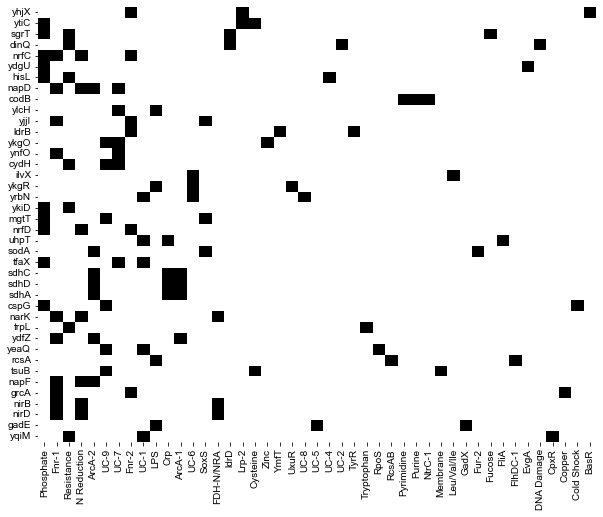

In [32]:
# plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df,
            cmap=['white', 'black'],
            xticklabels=True,
            yticklabels=True,
            linewidths=0.003, 
            linecolor='k', 
            cbar = False)
plt.show()

In [33]:
# functional categorization of selected iMs --  used for TRN map
ica_data.imodulon_table.loc[iM_list_ordered].functional_category

Phosphate          phosphate metabolism
Fnr-1                 energy metabolism
Resistance              envelope stress
N Reduction           energy metabolism
ArcA-2                energy metabolism
UC-9                            unknown
UC-7                            unknown
Fnr-2                 energy metabolism
UC-1                            unknown
LPS            extracellular structures
Crp                   carbon metabolism
ArcA-1                energy metabolism
UC-6                            unknown
SoxS                       redox stress
FDH-N/NRA             energy metabolism
ldrD                            unknown
Lrp-2             amino acid metabolism
Cysteine          amino acid metabolism
Zinc                  metal homeostasis
YmfT                         DNA damage
UxuR                  carbon metabolism
UC-8                            unknown
UC-5                            unknown
UC-4                            unknown
UC-2                            unknown


In [319]:
iM_of_interest = 'Cold Shock'

In [320]:
# iM size
ica_data.view_imodulon(iM_of_interest).shape[0]

13

In [321]:
# view iM genes in gene_im_df in ascending order of n_ims col
gene_im_df.loc[ica_data.view_imodulon(iM_of_interest).index.values].sort_values('n_ims', ascending = False)

,n_ims,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,regulator,in_iM
b0990,3.0,cspG,U00096.3,NaN,1051461,1051673,+,cold shock protein CspG,Transcription,P0A978,Op963,NaN,True
b0989,2.0,cspH,U00096.3,NaN,1050963,1051175,-,CspA family protein CspH,Transcription,P0A982,Op962,NaN,True
b1375,2.0,ynaE,U00096.3,NaN,1433991,1434224,-,uncharacterized protein YnaE,Transcription,P76073,Op1356,"GlaR,YdcR",True
b4744,2.0,ynaM,U00096.3,NaN,1434293,1434406,-,protein YnaM,No COG annotation,P0DPO4,Op1357,NaN,True
b1551,2.0,ynfN,U00096.3,NaN,1637954,1638109,-,protein YnfN,No COG annotation,P76157,Op1534,NaN,True
b4724,2.0,ynfQ,U00096.3,NaN,1638256,1638444,-,protein YnfQ,No COG annotation,P0DPC9,Op1536,NaN,True
b1552,2.0,cspI,U00096.3,NaN,1638455,1638667,-,cold shock-like protein CspI,Transcription,P0A986,Op1537,"BasR,Fis",True
b1557,2.0,cspB,U00096.3,NaN,1641339,1641554,-,cold shock-like protein CspB,Transcription,P36995,Op1544,"ZraR,RpoD",True
b4723,1.0,ymcF,U00096.3,NaN,1051684,1051872,+,protein YmcF,No COG annotation,P0DPC8,Op964,NaN,True
b4748,1.0,ynfT,U00096.3,NaN,1632890,1633003,+,protein YnfT,No COG annotation,P0DPO8,Op1525,NaN,True


In [322]:
# view iM genes in gene_im_df in ascending order of absolute gene weight in iM
gene_im_df.loc[ica_data.view_imodulon(iM_of_interest).sort_values('gene_weight', key = abs, ascending = False).index.values][:17]

,n_ims,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,regulator,in_iM
b4723,1.0,ymcF,U00096.3,NaN,1051684,1051872,+,protein YmcF,No COG annotation,P0DPC8,Op964,NaN,True
b0990,3.0,cspG,U00096.3,NaN,1051461,1051673,+,cold shock protein CspG,Transcription,P0A978,Op963,NaN,True
b4744,2.0,ynaM,U00096.3,NaN,1434293,1434406,-,protein YnaM,No COG annotation,P0DPO4,Op1357,NaN,True
b1557,2.0,cspB,U00096.3,NaN,1641339,1641554,-,cold shock-like protein CspB,Transcription,P36995,Op1544,"ZraR,RpoD",True
b4724,2.0,ynfQ,U00096.3,NaN,1638256,1638444,-,protein YnfQ,No COG annotation,P0DPC9,Op1536,NaN,True
b1552,2.0,cspI,U00096.3,NaN,1638455,1638667,-,cold shock-like protein CspI,Transcription,P0A986,Op1537,"BasR,Fis",True
b1375,2.0,ynaE,U00096.3,NaN,1433991,1434224,-,uncharacterized protein YnaE,Transcription,P76073,Op1356,"GlaR,YdcR",True
b4748,1.0,ynfT,U00096.3,NaN,1632890,1633003,+,protein YnfT,No COG annotation,P0DPO8,Op1525,NaN,True
b3556,1.0,cspA,U00096.3,NaN,3720049,3720261,+,cold shock protein CspA,Transcription,P0A9X9,Op3484,"H-NS,ppGpp,Fis,RpoD,CpxR,YdcN,YdhB,YdiP,YiaU",True
b2378,1.0,lpxP,U00096.3,NaN,2495645,2496565,+,palmitoleoyl acyltransferase,Cell wall/membrane/envelope biogenesis,P0ACV2,Op2352,"ppGpp,LldR,RpoE",True


In [323]:
# view iM genes in iM-specific table in ascending order of absolute gene weight in iM
ica_data.view_imodulon(iM_of_interest).sort_values('gene_weight', key = abs, ascending  = False)[:15]

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,regulator,in_iM
b4723,0.248218,ymcF,U00096.3,NaN,1051684,1051872,+,protein YmcF,No COG annotation,P0DPC8,Op964,NaN,True
b0990,0.233591,cspG,U00096.3,NaN,1051461,1051673,+,cold shock protein CspG,Transcription,P0A978,Op963,NaN,True
b4744,0.231961,ynaM,U00096.3,NaN,1434293,1434406,-,protein YnaM,No COG annotation,P0DPO4,Op1357,NaN,True
b1557,0.218430,cspB,U00096.3,NaN,1641339,1641554,-,cold shock-like protein CspB,Transcription,P36995,Op1544,"ZraR,RpoD",True
b4724,0.175746,ynfQ,U00096.3,NaN,1638256,1638444,-,protein YnfQ,No COG annotation,P0DPC9,Op1536,NaN,True
b1552,0.174963,cspI,U00096.3,NaN,1638455,1638667,-,cold shock-like protein CspI,Transcription,P0A986,Op1537,"BasR,Fis",True
b1375,0.170795,ynaE,U00096.3,NaN,1433991,1434224,-,uncharacterized protein YnaE,Transcription,P76073,Op1356,"GlaR,YdcR",True
b4748,0.146645,ynfT,U00096.3,NaN,1632890,1633003,+,protein YnfT,No COG annotation,P0DPO8,Op1525,NaN,True
b3556,0.146606,cspA,U00096.3,NaN,3720049,3720261,+,cold shock protein CspA,Transcription,P0A9X9,Op3484,"H-NS,ppGpp,Fis,RpoD,CpxR,YdcN,YdhB,YdiP,YiaU",True
b2378,0.141360,lpxP,U00096.3,NaN,2495645,2496565,+,palmitoleoyl acyltransferase,Cell wall/membrane/envelope biogenesis,P0ACV2,Op2352,"ppGpp,LldR,RpoE",True


In [313]:
# stringDB input
print(*ica_data.view_imodulon(iM_of_interest).index.values, sep = '\n')

b0060
b0231
b0779
b0958
b1061
b1183
b1184
b1728
b1741
b1847
b1848
b2009
b2616
b2698
b2699
b4613
b3645
b4618
b3832
b4043
b4044
b4058


In [40]:
# iM regulator (if available)
ica_data.imodulon_table.loc[iM_of_interest].regulator

nan

In [41]:
# check if regulator is in an iM
ica_data.imodulons_with('oxyR')

[]

## Fig. 6B

In [42]:
exp_var_series = ica_data.imodulon_table.loc[iM_list_ordered].groupby(['functional_category']).sum('explained_variance').explained_variance*100
exp_var_series

functional_category
DNA damage                  0.444565
amino acid metabolism       2.422309
carbon metabolism           2.124729
energy metabolism           7.038721
envelope stress             4.009129
extracellular structures    6.797939
global stress               7.911218
metal homeostasis           2.931844
nitrogen metabolism         2.054900
nucleotide metabolism       1.682657
phosphate metabolism        0.366543
redox stress                0.187213
temperature shock           0.516296
unknown                     7.253031
Name: explained_variance, dtype: float64

([<matplotlib.patches.Wedge at 0x1bfd27bc0d0>,
 [Text(1.0994872734872243, 0.033581772431333465, 'DNA damage'),
  Text(1.0716723936772647, 0.24802878992173838, 'amino acid metabolism'),
  Text(0.9436286063464857, 0.5653008520112006, 'carbon metabolism'),
  Text(0.4300772557285303, 1.012439407621521, 'energy metabolism'),
  Text(-0.3845079953157305, 1.0306083647721274, 'envelope stress'),
  Text(-0.9800012540609018, 0.49959737993614417, 'extracellular structures'),
  Text(-0.9441551205488525, -0.5644210381810568, 'global stress'),
  Text(-0.31166681349102493, -1.0549235978820224, 'metal homeostasis'),
  Text(0.060723869452955936, -1.098322635512289, 'nitrogen metabolism'),
  Text(0.33759059674947095, -1.0469157506630302, 'nucleotide metabolism'),
  Text(0.4811128712706889, -0.9892069576674407, 'phosphate metabolism'),
  Text(0.5183784953312867, -0.9701977816806588, 'redox stress'),
  Text(0.5646336767398578, -0.9440279715618759, 'temperature shock'),
  Text(0.9663129650930385, -0.5255846

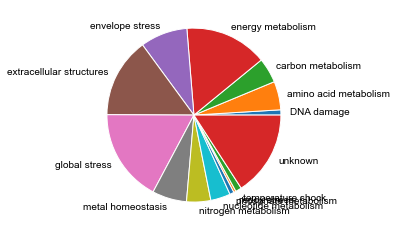

In [43]:
# pie chart of variance explained by selected 45 iMs grouped by functional category
exp_var_series = ica_data.imodulon_table.loc[iM_list_ordered].groupby(['functional_category']).sum('explained_variance').explained_variance*100
plt.pie(exp_var_series, labels = exp_var_series.index.values)

In [44]:
# total exp var of selected 45 iMs
ica_data.imodulon_table.loc[iM_list_ordered].explained_variance.sum()*100

45.7410945060184

In [45]:
# total exp var of all iMs
ica_data.imodulon_table.explained_variance.sum()*100

75.45051116888885